### Architecture
In this experiment swin tranformer model is taken and applied on images with final head removal and single pawpularity output is added. In addition, Strong Augmentation is added to generalize the model including horizontal, vertical flipping, Random Rotation, Brightness, etc.
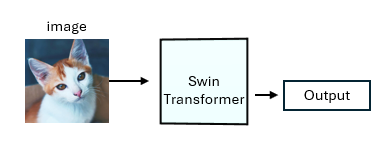




In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../.."))

In [3]:
# imports and config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import gc

gc.enable()

import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config
from src.data import build_transforms, ImageOnlyDataset
from src.models import build_vision_backbone
from src.train import train_one_epoch_image, validate_image

main_folder = "../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp3_swin_384_strong_hub")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp3"]
cfg["loss"] = "huber"
cfg["name"] = "exp3_swin_384_strong_hub"
TARGET = "Pawpularity"
os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold
import time

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
        fold=fold,
        train_df=train_df,
        val_df=val_df,
        img_folder=img_folder,
        cfg=cfg,
        out_dir=out_dir,
        device=device,
        mode="image",
        tab_cols=None,
        workers=16,
        pin_memory=True,
        persistent_workers=True,
    )

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")


all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,      
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")



=== exp3_swin_384_strong_hub: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[HUBER]: Loss=15.1414 | ValRMSE: 21.1722
Epoch 2/10 | Fold 1 | Train[HUBER]: Loss=13.6924 | ValRMSE: 20.2011
Epoch 3/10 | Fold 1 | Train[HUBER]: Loss=12.9324 | ValRMSE: 19.1130
Epoch 4/10 | Fold 1 | Train[HUBER]: Loss=12.3853 | ValRMSE: 19.0890
Epoch 5/10 | Fold 1 | Train[HUBER]: Loss=11.8432 | ValRMSE: 18.6926
Epoch 6/10 | Fold 1 | Train[HUBER]: Loss=11.3361 | ValRMSE: 18.3003
Epoch 7/10 | Fold 1 | Train[HUBER]: Loss=10.8579 | ValRMSE: 18.1154
Epoch 8/10 | Fold 1 | Train[HUBER]: Loss=10.5122 | ValRMSE: 18.1182
Epoch 9/10 | Fold 1 | Train[HUBER]: Loss=10.2531 | ValRMSE: 18.1029
Epoch 10/10 | Fold 1 | Train[HUBER]: Loss=10.0122 | ValRMSE: 18.0997
Fold 1 best RMSE: 18.0997

=== exp3_swin_384_strong_hub: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[HUBER]: Loss=15.1470 | ValRMSE: 20.6151
Epoch 2/10 | Fold 2 | Train[HUBER]: Loss=13.4810 | ValRMSE: 20.5535
Epoch 3/10 | Fold 2 | Train[HUBER]: Loss=12.7518 | ValRMSE: 19.4566
Epoch

In [4]:
import pandas
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 18.0997 (n=1983)
Fold 2 OOF RMSE: 18.1295 (n=1983)
Fold 3 OOF RMSE: 17.3720 (n=1982)
Fold 4 OOF RMSE: 18.1139 (n=1982)
Fold 5 OOF RMSE: 18.1527 (n=1982)


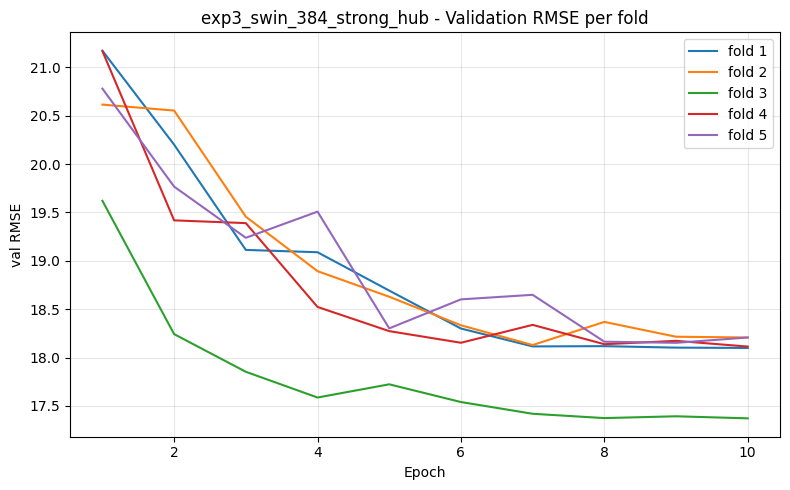

In [5]:
from src.plot import plot_all_folds_history
plot_all_folds_history(out_dir, folds=[1,2,3,4,5], title_prefix="exp3_swin_384_strong_hub")

In [6]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()


,Id,fold,ytrue,oof_pred,abs_err
0,48a66727373de4e7fa7bb3331cd9acc8,3,96,20.837835,75.162165
1,4435d6f98ad72782ca0cf61f946b016d,5,100,25.306845,74.693155
2,f7903a7d6be4a636f8c28fd23b4951ec,4,100,26.130665,73.869335
3,e638853bdec13e6cc76b69f169b34740,4,96,22.256351,73.743649
4,f5e841dbe4a37954cd762022af45896b,4,100,26.953117,73.046883


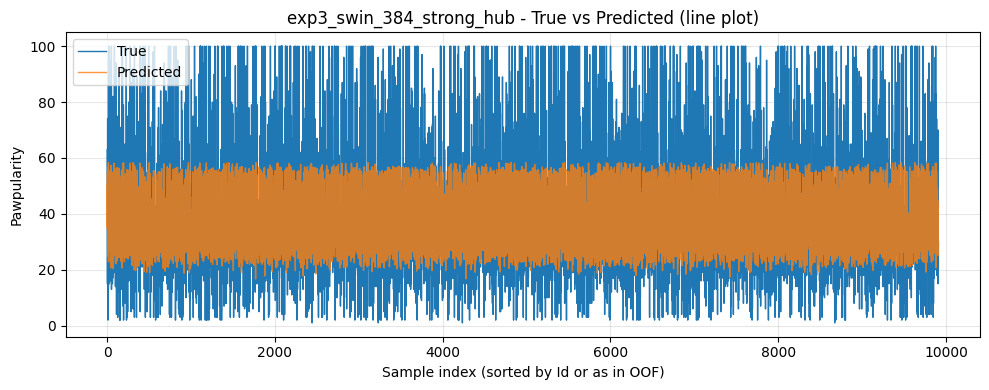

In [8]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plots
plot_oof_true_pred_lines(oof_df, title_prefix="exp3_swin_384_strong_hub")





Exp3_Swin_NoFusion_HuberLoss OOF RMSE: 17.976095518803394
Exp3_Swin_NoFusion_BCELoss OOF RMSE: 17.714745225456582
ΔRMSE (Exp3_Swin_NoFusion_BCELoss - Exp3_Swin_NoFusion_HuberLoss): -0.2613502933468119


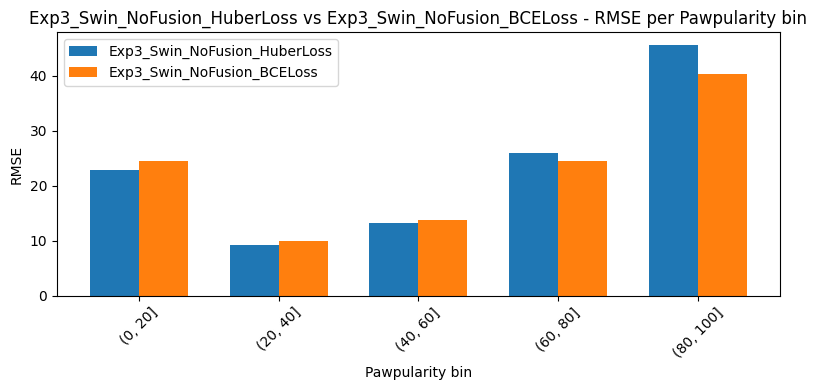

In [10]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a="../../outputs/extra/exp3_swin_384_strong_hub/oof_detail.csv",
    oof_path_b="../../outputs/exp3/oof_detail.csv",
    bins=bins,
    label_a="Exp3_Swin_NoFusion_HuberLoss",
    label_b="Exp3_Swin_NoFusion_BCELoss",
    title_prefix="Exp3_Swin_NoFusion_HuberLoss vs Exp3_Swin_NoFusion_BCELoss",
)

In [11]:
df_bins.head()

,bin,count,Exp3_Swin_NoFusion_HuberLoss_rmse,Exp3_Swin_NoFusion_BCELoss_rmse,rmse_diff,winner
0,"(0, 20]",1417,22.815804,24.496437,1.680634,Exp3_Swin_NoFusion_HuberLoss_better
1,"(20, 40]",5119,9.299777,9.970236,0.670459,Exp3_Swin_NoFusion_HuberLoss_better
2,"(40, 60]",2088,13.208550,13.859223,0.650673,Exp3_Swin_NoFusion_HuberLoss_better
3,"(60, 80]",727,25.929684,24.577702,-1.351981,Exp3_Swin_NoFusion_BCELoss_better
4,"(80, 100]",561,45.658696,40.300325,-5.358371,Exp3_Swin_NoFusion_BCELoss_better


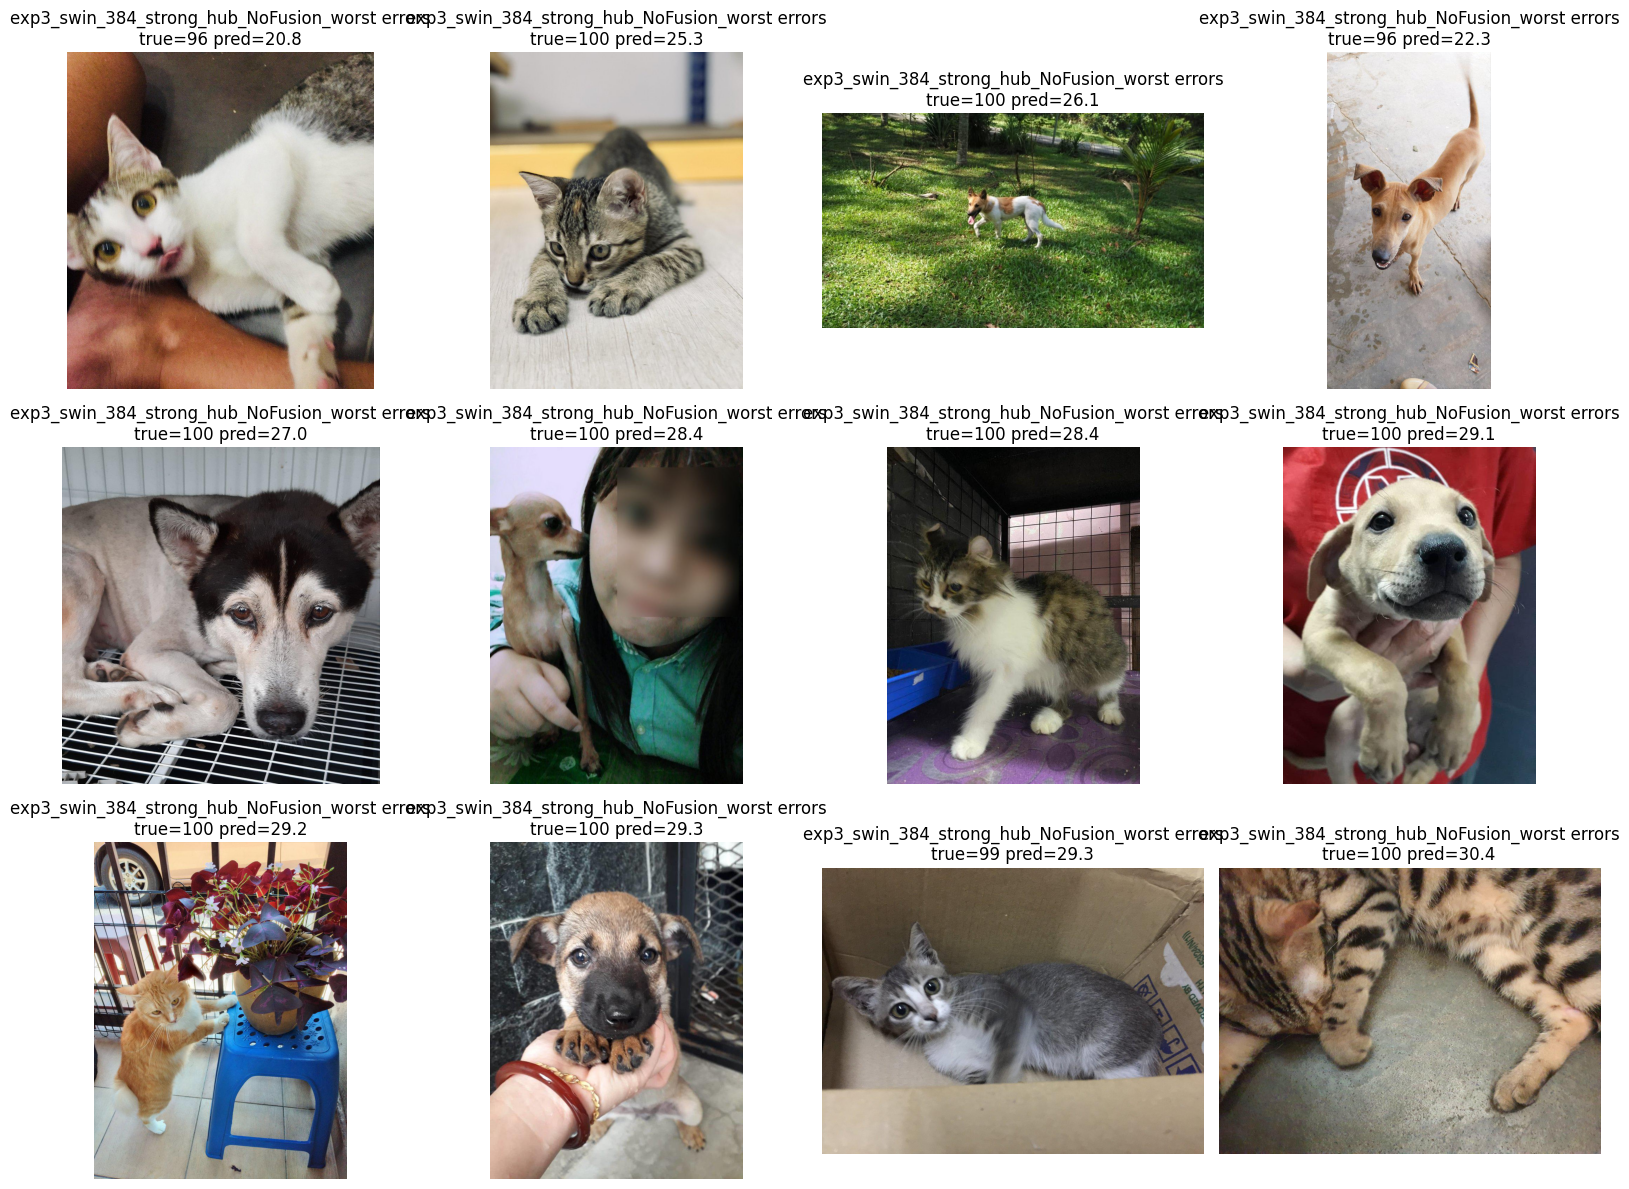

In [14]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="exp3_swin_384_strong_hub_NoFusion_worst errors")

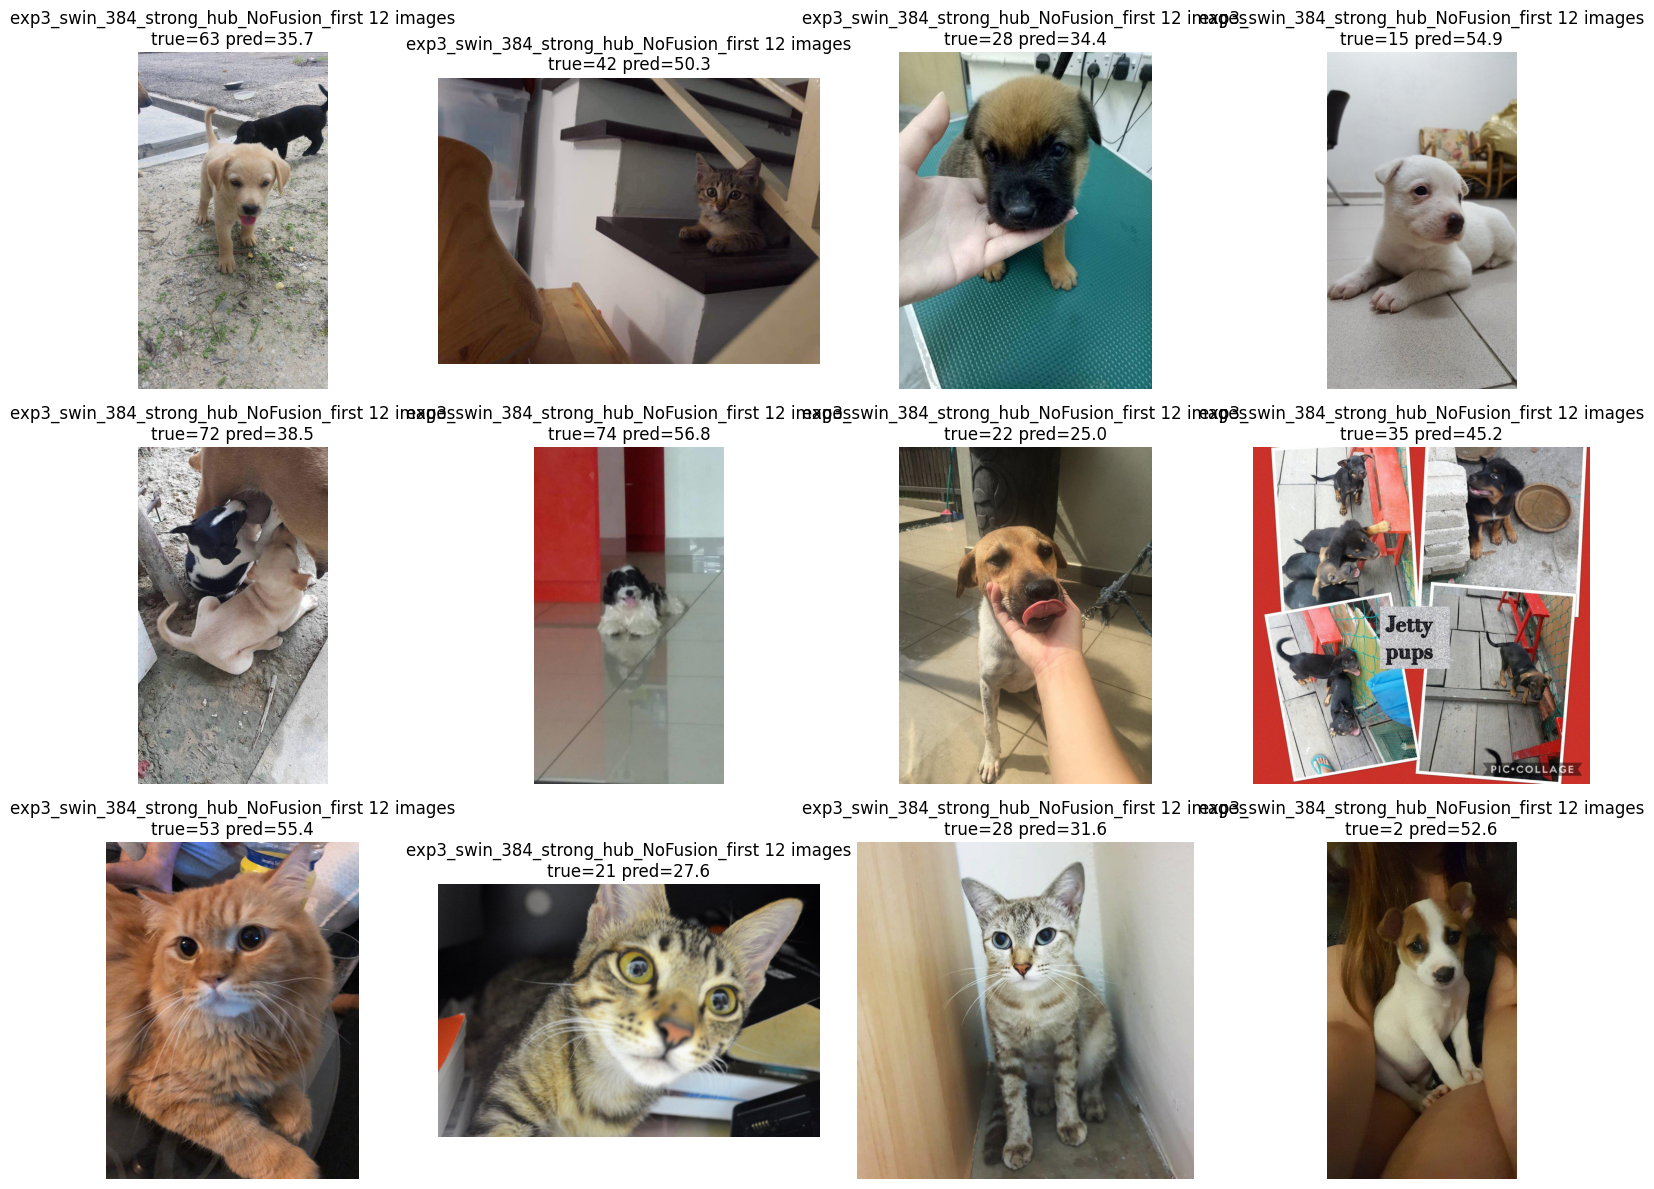

In [15]:
# Images of worst errors
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(oof_df, img_folder, n=12, title_prefix="exp3_swin_384_strong_hub_NoFusion_first 12 images")